# Tutorial 8 — Handling Missing Observations

Real-world time-series are rarely complete. Sensors drop out, experiments are
paused, particles leave the field of view. This tutorial covers three missingness
patterns that dynestyx handles without any preprocessing on the user's side.

| Section | Missingness pattern | How it's handled |
|---|---|---|
| 3 | Whole-row: all dims NaN at some timesteps | Full-length unrolled scan (default) or row-filter with shorter output |
| 4 | Per-dimension: some dims NaN within the same row | Per-step scan using `masked_log_prob` (diagonal obs model required) |
| 5 | Per-particle contiguous gaps (interacting systems) | Per-step scan; gap states are latent variables (SVI) |

Sections 1–4 use a 2-D AR(1) model. Section 5 switches to interacting particles
to show how the framework scales to richer dynamics.

In [1]:
import time

import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx.models import DiagonalLinearGaussianObservation, DynamicalModel
from dynestyx.models.observations import DiracIdentityObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution
from dynestyx.simulators import DiscreteTimeSimulator

az.style.use("arviz-white")

## 1. The model

We use a 2-D AR(1) state-space system with **diagonal** Gaussian observations:

$$
\begin{aligned}
x_0 &\sim \mathcal{N}(0,\, I_2) \\[4pt]
x_{t+1} &\sim \mathcal{N}\!\left(\begin{pmatrix}\alpha & 0.2 \\ -0.1 & 0.8\end{pmatrix} x_t,\;\; \begin{pmatrix}0.1 & 0.01\\-0.01 & 0.15\end{pmatrix}\right) \\[4pt]
y_t^{(d)} &\sim \mathcal{N}(x_t^{(d)},\; 0.25), \quad d \in \{0, 1\}
\end{aligned}
$$

The two dimensions are **independent** in the observations,
which is precisely why `DiagonalLinearGaussianObservation` can score
them separately — a requirement for per-dimension partial missingness.

The single unknown is $\alpha \in (-0.7, 0.7)$, the first dimension's
autocorrelation. We set the true value to $\alpha^* = 0.4$.

In [19]:
obs_times  = jnp.arange(0.0, 1000.0, 1.0)   # T = 100 timesteps
true_alpha = 0.4
state_dim  = 2


def ar1_model(obs_times=None, obs_values=None):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            jnp.zeros(state_dim), jnp.eye(state_dim)
        ),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[alpha, 0.2], [-0.1, 0.8]]),
            cov=jnp.array([[0.1, 0.01], [-0.01, 0.15]]),
        ),
        observation_model=DiagonalLinearGaussianObservation(
            H=jnp.eye(state_dim),
            R_diag=jnp.array([0.25, 0.25]),
        ),
    )
    dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)

## 2. Generating synthetic data

We fix $\alpha = 0.4$ and draw one synthetic trajectory. The two plots below
show the latent states and observations for each dimension.

In [20]:
data_key, mcmc_key1, mcmc_key2, mcmc_key3, pp_key = jr.split(jr.PRNGKey(0), 5)

n_mcmc_samples = 5000

with DiscreteTimeSimulator():
    synthetic = Predictive(
        ar1_model,
        params={"alpha": jnp.array(true_alpha)},
        num_samples=1,
        exclude_deterministic=False,
    )(data_key, obs_times=obs_times)

states_clean = np.asarray(synthetic["states"].squeeze(0))     # (T, 2)
obs_clean    = np.asarray(synthetic["observations"].squeeze(0))  # (T, 2)
t            = np.asarray(obs_times)

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/3075684453.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


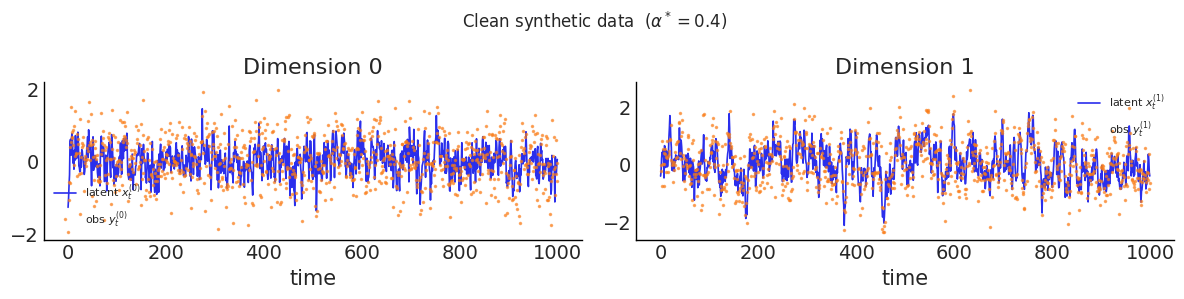

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.2, label=f"latent $x^{{({d})}}_t$")
    ax.plot(t, obs_clean[:, d], ".", ms=3, color="C1", alpha=0.6, label=f"obs $y^{{({d})}}_t$")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Clean synthetic data  ($\\alpha^* = 0.4$)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Whole-row missingness

A **whole-row missing** observation means all $d_y$ dimensions are `NaN` at
that timestep. This is the most common pattern: the sensor was simply off.

We blank out a contiguous block in the middle of the series — rows 35–60.

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/2523471794.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


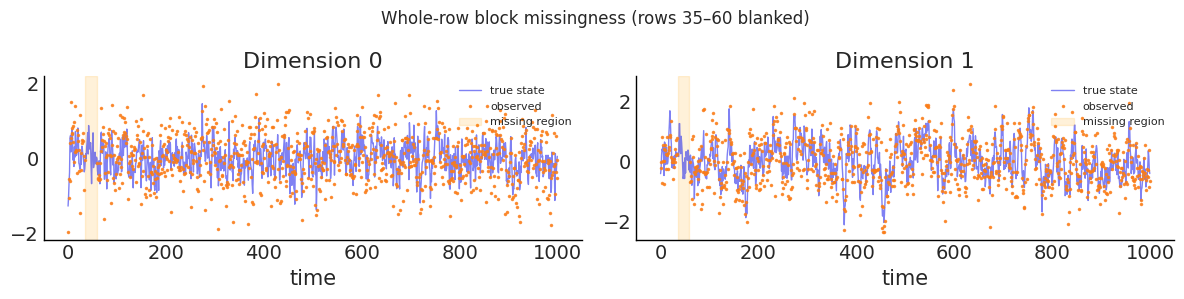

In [22]:
block_start, block_end = 35, 60

obs_block = np.where(
    (np.arange(len(t))[:, None] >= block_start)
    & (np.arange(len(t))[:, None] < block_end),
    np.nan,
    obs_clean,
)
obs_block = jnp.array(obs_block)


def _shade_gap(ax, t, start, end):
    ax.axvspan(t[start], t[end - 1], color="orange", alpha=0.15, zorder=0,
               label="missing region")


fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.0, alpha=0.6, label="true state")
    obs_d = np.asarray(obs_block[:, d])
    ax.plot(t[~np.isnan(obs_d)], obs_d[~np.isnan(obs_d)], ".", ms=3,
            color="C1", alpha=0.8, label="observed")
    _shade_gap(ax, t, block_start, block_end)
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Whole-row block missingness (rows 35–60 blanked)", fontsize=12)
plt.tight_layout()
plt.show()

### 3.1 Full-length output (default)

With `unroll_missing=True` (the default), dynestyx keeps **all** $T$ timesteps.
For missing rows the observation log-likelihood is zeroed out, but the latent
state $x_t$ is still sampled from the transition. This enables:

- a full-length state trajectory in the output,
- **gap imputation** via posterior predictive sampling.

In [23]:
def conditioned_unrolled():
    with DiscreteTimeSimulator():   # default: unroll_missing=True
        ar1_model(obs_times=obs_times, obs_values=obs_block)


mcmc2 = MCMC(NUTS(conditioned_unrolled), num_warmup=n_mcmc_samples, num_samples=n_mcmc_samples, progress_bar=False)
mcmc2.run(mcmc_key2)

states_unrolled = np.asarray(mcmc2.get_samples()["states"])

assert states_unrolled.shape[1] == len(obs_times), "Output trajectory length mismatch"

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/19309749.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


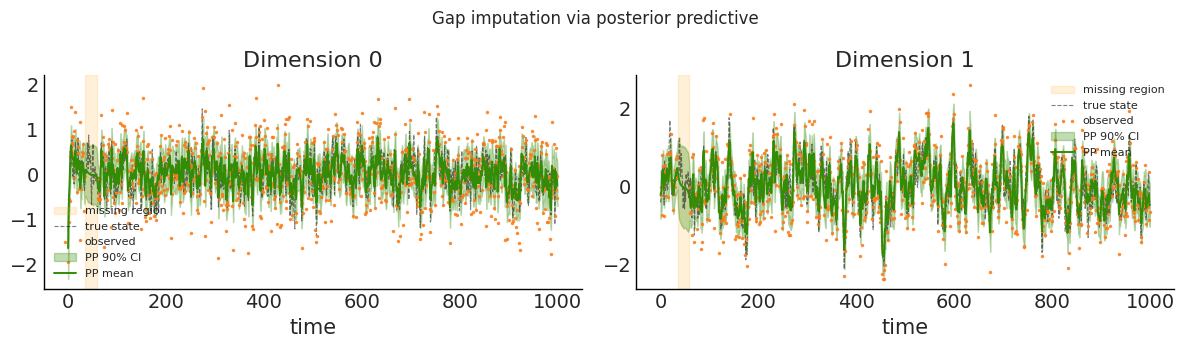

In [24]:
# Posterior predictive: re-run the model with posterior alpha samples to get
# imputed state distributions.  States during the gap are drawn from the
# transition posterior because no likelihood constrains them there.
pp = Predictive(ar1_model, posterior_samples=mcmc2.get_samples())
with DiscreteTimeSimulator():
    pp_out = pp(pp_key, obs_times=obs_times, obs_values=obs_block)

pp_states = np.asarray(pp_out["states"])   # (n_samples, T, 2)
pp_mean = pp_states.mean(0)
pp_lo   = np.percentile(pp_states,  5, axis=0)
pp_hi   = np.percentile(pp_states, 95, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
for d, ax in enumerate(axes):
    _shade_gap(ax, t, block_start, block_end)
    ax.plot(t, states_clean[:, d], color="black", lw=0.8, ls="--", alpha=0.5,
            label="true state")
    obs_d = np.asarray(obs_block[:, d])
    ax.plot(t[~np.isnan(obs_d)], obs_d[~np.isnan(obs_d)], ".", ms=3,
            color="C1", alpha=0.8, label="observed")
    ax.fill_between(t, pp_lo[:, d], pp_hi[:, d], color="C2", alpha=0.3,
                    label="PP 90% CI")
    ax.plot(t, pp_mean[:, d], color="C2", lw=1.4, label="PP mean")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Gap imputation via posterior predictive", fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 The row-filter path: `unroll_missing=False`

Setting `unroll_missing=False` **filters out** entirely-missing rows before
passing data to the simulator. The model sees a *shorter* series of
$T - n_{\text{missing}}$ timesteps — completely transparent to the model code.

This is always correct for **any** observation model, but it means the output
trajectory is shorter and there are no imputed states for the gap.

In [25]:
def conditioned_filtered():
    with DiscreteTimeSimulator(unroll_missing=False):
        ar1_model(obs_times=obs_times, obs_values=obs_block)


mcmc1 = MCMC(NUTS(conditioned_filtered), num_warmup=n_mcmc_samples, num_samples=n_mcmc_samples, progress_bar=False)
mcmc1.run(mcmc_key1)

states_filtered = np.asarray(mcmc1.get_samples()["states"]) 
print(f"Input timesteps: {len(obs_times)},  "
      f"Output trajectory length: {states_filtered.shape[1]}")
print(f"Rows dropped: {len(obs_times) - states_filtered.shape[1]}")

Input timesteps: 1000,  Output trajectory length: 975
Rows dropped: 25


### 3.3 Comparing posteriors

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/1344315514.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


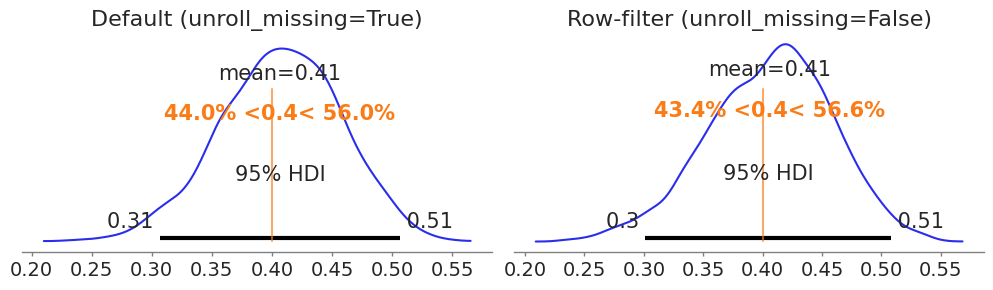

In [26]:
posterior_alpha1 = mcmc1.get_samples()["alpha"]
posterior_alpha2 = mcmc2.get_samples()["alpha"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
az.plot_posterior(posterior_alpha2, hdi_prob=0.95, ref_val=true_alpha, ax=axes[0])
axes[0].set_title("Default (unroll_missing=True)")
az.plot_posterior(posterior_alpha1, hdi_prob=0.95, ref_val=true_alpha, ax=axes[1])
axes[1].set_title("Row-filter (unroll_missing=False)")
plt.tight_layout()
plt.show()

## 4. Per-dimension partial missingness

A **partial** observation has some dimensions observed and others `NaN` within
the *same row*. This is more demanding than whole-row missingness.

### Why diagonal observation models are required

For a fully correlated Gaussian observation
$y_t \sim \mathcal{N}(Hx_t,\, R)$ with off-diagonal $R$, the marginal
likelihood of the observed subset depends on the covariance between observed
and missing dimensions — there is no clean per-dimension factorisation.

`DiagonalLinearGaussianObservation` (and its nonlinear counterpart
`DiagonalGaussianObservation`) store $R = \mathrm{diag}(r_1, \ldots, r_{d_y})$,
so the joint factors as:

$$
\log p(y_t^{\text{obs}} \mid x_t) = \sum_{d:\, m_d = 1} \log \mathcal{N}(y_t^{(d)};\; h_d(x_t),\; r_d)
$$

where $m_d \in \{0,1\}$ is the observation mask for dimension $d$.
This is precisely what `masked_log_prob` computes.

When the data array contains per-dimension `NaN` values, dynestyx detects
the partial pattern automatically and activates a per-step scan — no extra
flag is needed.

We randomly blank ~20% of individual elements (per-dimension, not per-row).

In [36]:
partial_key = jr.PRNGKey(7)
mask_partial = jr.bernoulli(partial_key, p=0.9, shape=obs_clean.shape)
obs_partial  = jnp.where(mask_partial, jnp.array(obs_clean), jnp.nan)

# Sanity check: there should be rows with some-but-not-all NaN.
nan_any = jnp.isnan(obs_partial).any(axis=1)
nan_all = jnp.isnan(obs_partial).all(axis=1)
n_partial_rows = int((nan_any & ~nan_all).sum())
print(f"Rows with at least one NaN:      {int(nan_any.sum())}")
print(f"  of which partial (not all-NaN): {n_partial_rows}")
print(f"  of which fully missing:         {int(nan_all.sum())}"  )

Rows with at least one NaN:      188
  of which partial (not all-NaN): 178
  of which fully missing:         10


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/3717764827.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


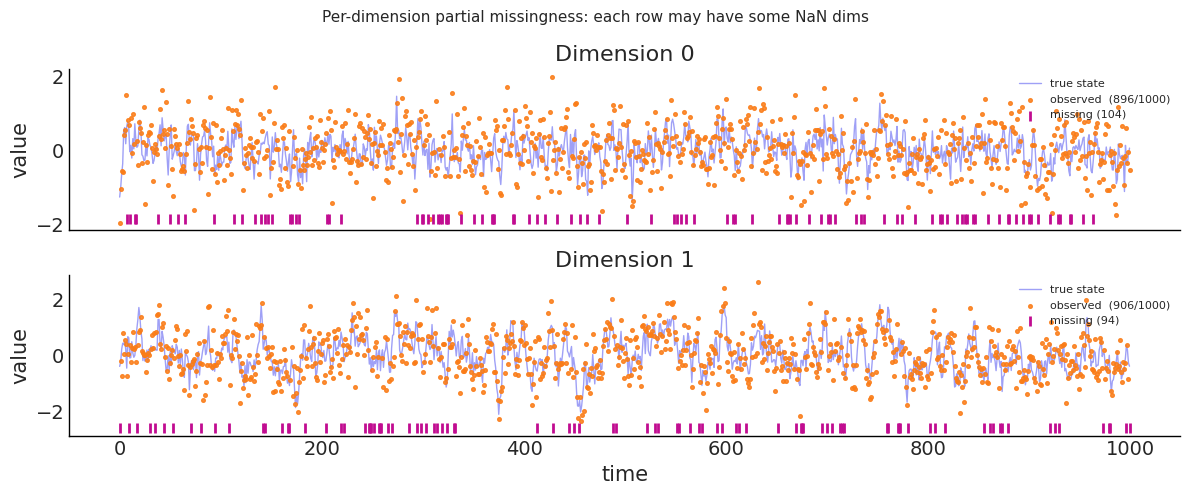

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for d, ax in enumerate(axes):
    obs_d = np.asarray(obs_partial[:, d])
    missing = np.isnan(obs_d)
    ax.plot(t, states_clean[:, d], color="C0", lw=1.0, alpha=0.45, label="true state")
    ax.scatter(t[~missing], obs_d[~missing], s=7, color="C1", alpha=0.85, zorder=3,
               label=f"observed  ({(~missing).sum()}/{len(t)})")
    # Rug at bottom: one tick per missing entry
    ylo = np.nanmin(states_clean[:, d]) - 0.5
    ax.scatter(t[missing], np.full(missing.sum(), ylo), s=50, marker="|",
               color="C3", linewidths=2, zorder=4, label=f"missing ({missing.sum()})")
    ax.set_ylabel("value")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
axes[-1].set_xlabel("time")
fig.suptitle("Per-dimension partial missingness: each row may have some NaN dims", fontsize=11)
plt.tight_layout()
plt.show()

In [45]:
# Per-dim partial NaN is detected automatically — the simulator switches
# to a per-step scan that scores each dimension individually.
def conditioned_partial():
    with DiscreteTimeSimulator():
        ar1_model(obs_times=obs_times, obs_values=obs_partial)


mcmc3 = MCMC(NUTS(conditioned_partial), num_warmup=n_mcmc_samples, num_samples=n_mcmc_samples, progress_bar=False)
mcmc3.run(mcmc_key3)

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/330669405.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


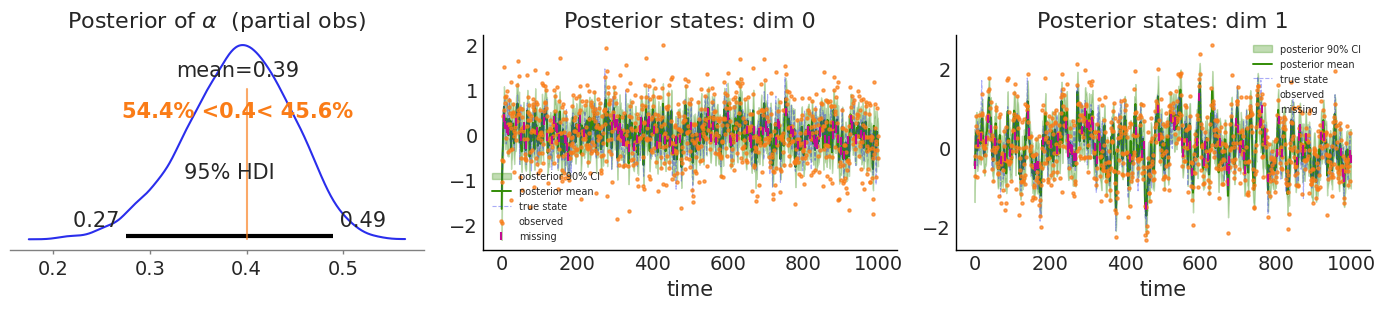

In [46]:
posterior_alpha3  = mcmc3.get_samples()["alpha"]
posterior_states3 = np.asarray(mcmc3.get_samples()["states"])  # (S, T, 2)

pp_mean3 = posterior_states3.mean(0)
pp_lo3   = np.percentile(posterior_states3,  5, axis=0)
pp_hi3   = np.percentile(posterior_states3, 95, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))

az.plot_posterior(posterior_alpha3, hdi_prob=0.95, ref_val=true_alpha, ax=axes[0])
axes[0].set_title("Posterior of $\\alpha$  (partial obs)")

for d, ax in enumerate(axes[1:], start=0):
    obs_d = np.asarray(obs_partial[:, d])
    missing = np.isnan(obs_d)
    ax.fill_between(t, pp_lo3[:, d], pp_hi3[:, d], color="C2", alpha=0.3,
                    label="posterior 90% CI")
    ax.plot(t, pp_mean3[:, d], color="C2", lw=1.4, label="posterior mean")
    ax.plot(t, states_clean[:, d], color="C0", lw=0.8, ls="--", alpha=0.4,
            label="true state")
    ax.scatter(t[~missing], obs_d[~missing], s=5, color="C1", alpha=0.7, zorder=3,
               label="observed")
    ax.scatter(t[missing], np.full(missing.sum(), ax.get_ylim()[0] if False else
               pp_mean3[missing, d]), s=30, marker="|", color="C3", linewidths=1.5,
               zorder=4, label="missing")
    ax.set_title(f"Posterior states: dim {d}")
    ax.set_xlabel("time")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 5. Per-particle trajectory gaps (interacting systems)

$N = 20$ interacting particles in 1D, each dropping out for a contiguous segment at a
different time — a common pattern in tracking experiments.

### The model

$$
x^{(i)}_{t+1} = x^{(i)}_t
  + \Delta t \underbrace{\frac{\text{coefficient}}{N}\sum_j K(x^{(j)}_t - x^{(i)}_t;\,\text{scale})\,(x^{(j)}_t-x^{(i)}_t)}_{\text{pairwise repulsion}}
  + \Delta t \underbrace{\nabla_{\!x^{(i)}} V_{\text{bg}}(x^{(i)}_t)}_{\text{background wells}}
  + \sigma\sqrt{\Delta t}\,\varepsilon_t
$$

Background potential: two Gaussian wells at $-2$ and $+2$.
Learnable parameters: **coefficient** (negative = repulsion) and **scale** (kernel width).

Observations use `DiracIdentityObservation` — positions are observed exactly when
available. Each particle's gap starts at a different time, so most rows have a mix
of observed and missing particles. dynestyx detects the partial pattern automatically
and uses SVI with a correction-factor approach to infer both the model parameters
and the missing gap states.

In [47]:
# ---- Parameters -----------------------------------------------------------
N_p            = 20
obs_times_p    = jnp.arange(0.0, 30 * 0.1, 0.1)   # T=30 steps, dt=0.1
sigma_p        = 0.2
bg_centers_p   = jnp.array([[-2.0], [2.0]])
bg_strengths_p = jnp.array([1.0, 1.0])

true_coeff = -1.0    # negative = repulsion within each well
true_scale = 1.0     # kernel width


# ---- Model -----------------------------------------------------------------
def interacting_particles_model(N, obs_times=None, obs_values=None):
    coefficient = numpyro.sample("coefficient", dist.Normal(0.0, 2.0))
    scale       = numpyro.sample("scale",       dist.LogNormal(0.0, 0.5))

    def state_evolution(x, u, t_now, t_next):
        dt = t_next - t_now
        r      = x[None, :] - x[:, None]              # (N, N) pairwise separations
        K_pair = jnp.exp(-0.5 * (r / scale) ** 2)
        interaction_drift = coefficient * jnp.sum(K_pair * r, axis=1) / N
        # Background: -grad V,  V = -sum_k bg_strengths[k] * exp(-||x - c_k||^2 / 2)
        diffs   = x[:, None] - bg_centers_p[:, 0][None, :]  # (N, K)
        kernels = jnp.exp(-0.5 * diffs ** 2)
        bg_drift = -jnp.sum(bg_strengths_p[None, :] * diffs * kernels, axis=1)
        mean = x + dt * (interaction_drift + bg_drift)
        std  = jnp.sqrt(sigma_p ** 2 * dt) * jnp.ones_like(mean)
        return dist.Independent(dist.Normal(mean, std), 1)

    dynamics = DynamicalModel(
        control_dim=0,
        initial_condition=dist.Independent(
            dist.Normal(jnp.zeros(N), jnp.full(N, jnp.sqrt(8.0))), 1
        ),
        state_evolution=state_evolution,
        observation_model=DiracIdentityObservation(),
    )
    dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)


# ---- Generate clean data ---------------------------------------------------
data_key_p, svi_key_p, pp_key_p = jr.split(jr.PRNGKey(5), 3)

true_params_p = {"coefficient": jnp.array(true_coeff), "scale": jnp.array(true_scale)}
with DiscreteTimeSimulator():
    synth_p = Predictive(
        interacting_particles_model,
        params=true_params_p,
        num_samples=1,
        exclude_deterministic=False,
    )(data_key_p, N=N_p, obs_times=obs_times_p)

states_p    = np.asarray(synth_p["states"].squeeze(0))       # (T, N)
obs_clean_p = np.asarray(synth_p["observations"].squeeze(0)) # (T, N)
t_p         = np.asarray(obs_times_p)

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/3536063595.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


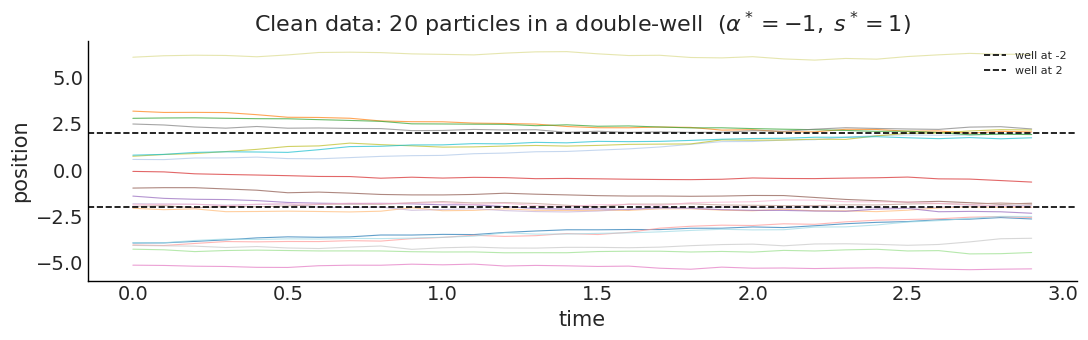

In [48]:
fig, ax = plt.subplots(figsize=(11, 3.5))
colors_p = plt.cm.tab20(np.linspace(0, 1, N_p))  # type: ignore[attr-defined]
for i in range(N_p):
    ax.plot(t_p, obs_clean_p[:, i], color=colors_p[i], lw=0.8, alpha=0.7)
for k in range(bg_centers_p.shape[0]):
    ax.axhline(bg_centers_p[k, 0].item(), color="black", ls="--", lw=1.2,
               label=f"well at {bg_centers_p[k,0].item():.0f}")
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title(f"Clean data: {N_p} particles in a double-well  "
             r"($\alpha^* = -1,\; s^* = 1$)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

Rows with partial missingness (some but not all particles missing): 23
Fully-missing rows: 0


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/2432094799.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


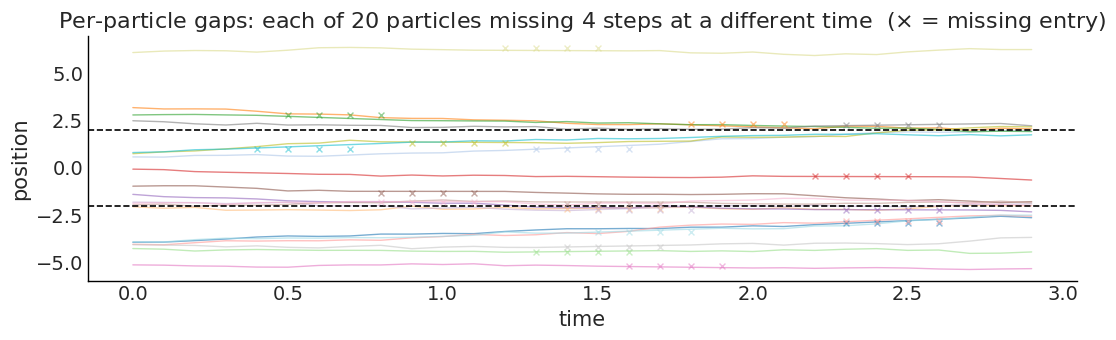

In [49]:
# Each particle gets its own randomly-timed gap of length 4
gap_len_p = 4
rng_gap = np.random.default_rng(99)
T_p = len(t_p)
gap_starts_p = rng_gap.integers(2, T_p - gap_len_p - 2, size=N_p)

obs_block_p = obs_clean_p.copy()
for i in range(N_p):
    obs_block_p[gap_starts_p[i]:gap_starts_p[i] + gap_len_p, i] = np.nan
obs_block_p = jnp.array(obs_block_p)

obs_np_p = np.asarray(obs_block_p)
nan_any_p = np.isnan(obs_np_p).any(axis=1)
nan_all_p = np.isnan(obs_np_p).all(axis=1)
n_partial_p = int((nan_any_p & ~nan_all_p).sum())
print(f"Rows with partial missingness (some but not all particles missing): {n_partial_p}")
print(f"Fully-missing rows: {int(nan_all_p.sum())}")

fig, ax = plt.subplots(figsize=(11, 3.5))
colors_p = plt.cm.tab20(np.linspace(0, 1, N_p))  # type: ignore[attr-defined]
for i in range(N_p):
    obs_i = obs_np_p[:, i]
    observed = ~np.isnan(obs_i)
    ax.plot(t_p[observed], obs_i[observed], color=colors_p[i], lw=1.0, alpha=0.6)
    gap_t = t_p[gap_starts_p[i]:gap_starts_p[i] + gap_len_p]
    ax.scatter(gap_t, np.full(len(gap_t), obs_clean_p[gap_starts_p[i], i]),
               s=18, marker="x", color=colors_p[i], linewidths=1.0, alpha=0.5, zorder=3)
for k in range(bg_centers_p.shape[0]):
    ax.axhline(bg_centers_p[k, 0].item(), color="black", ls="--", lw=1.2)
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title(f"Per-particle gaps: each of {N_p} particles missing 4 steps at a different time  "
             r"($\times$ = missing entry)")
plt.tight_layout()
plt.show()

SVI finished in 1.3s


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/494930620.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


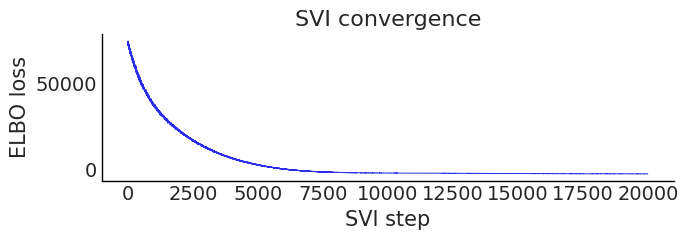

In [50]:
# With DiracIdentityObservation, gap states become latent variables.
# The simulator uses a correction-factor approach so that SVI can optimise
# the ELBO over both parameters and gap trajectories.
def conditioned_particles():
    with DiscreteTimeSimulator():
        interacting_particles_model(N=N_p, obs_times=obs_times_p, obs_values=obs_block_p)


init_vals_p = {"coefficient": jnp.array(true_coeff), "scale": jnp.array(true_scale)}
guide_p   = AutoNormal(conditioned_particles, init_loc_fn=init_to_value(values=init_vals_p))
svi_p     = SVI(conditioned_particles, guide_p, optax.adam(1e-3), loss=Trace_ELBO())

t0 = time.time()
svi_res_p = svi_p.run(svi_key_p, num_steps=20000, progress_bar=False)
print(f"SVI finished in {time.time() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(svi_res_p.losses, lw=0.7, color="C0")
ax.set_xlabel("SVI step")
ax.set_ylabel("ELBO loss")
ax.set_title("SVI convergence")
plt.tight_layout()
plt.show()

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/2172548230.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


coefficient:  true -1.0  |  SVI mean -0.799 ± 0.419
scale:        true 1.0   |  SVI mean 0.745 ± 0.179


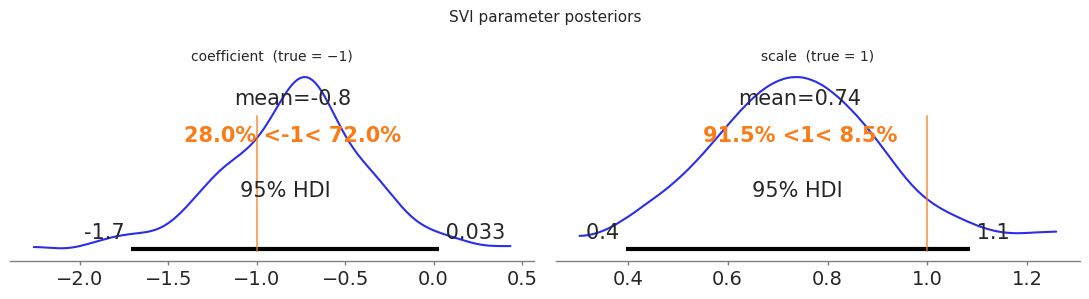

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/2172548230.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


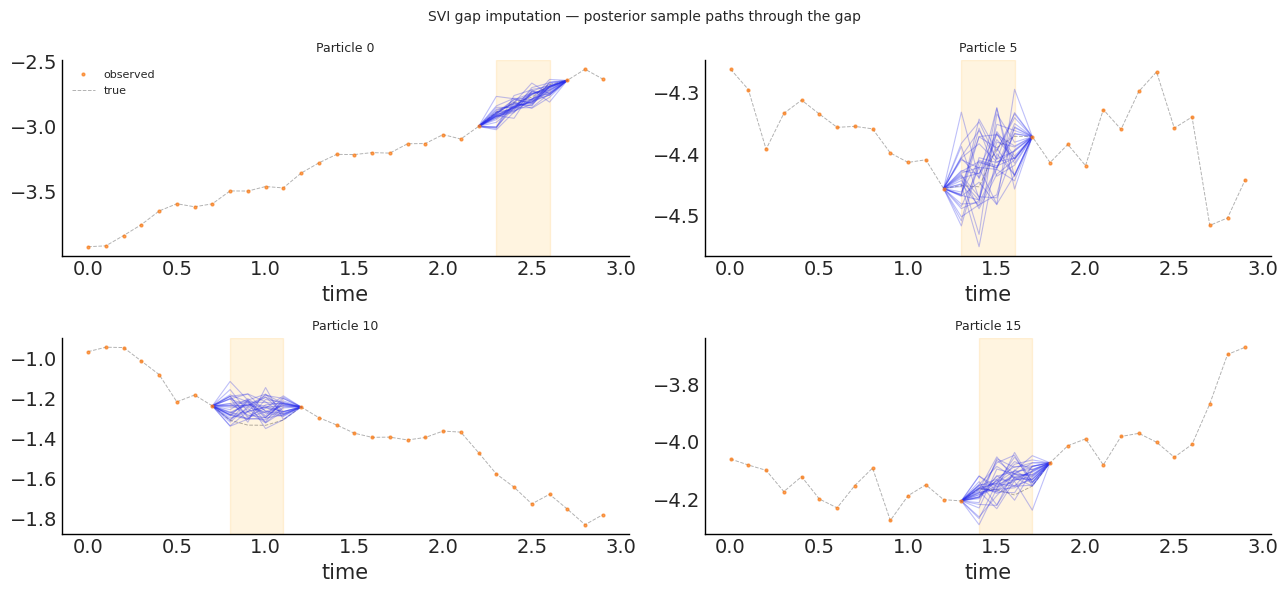

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_7787/2172548230.py:81: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


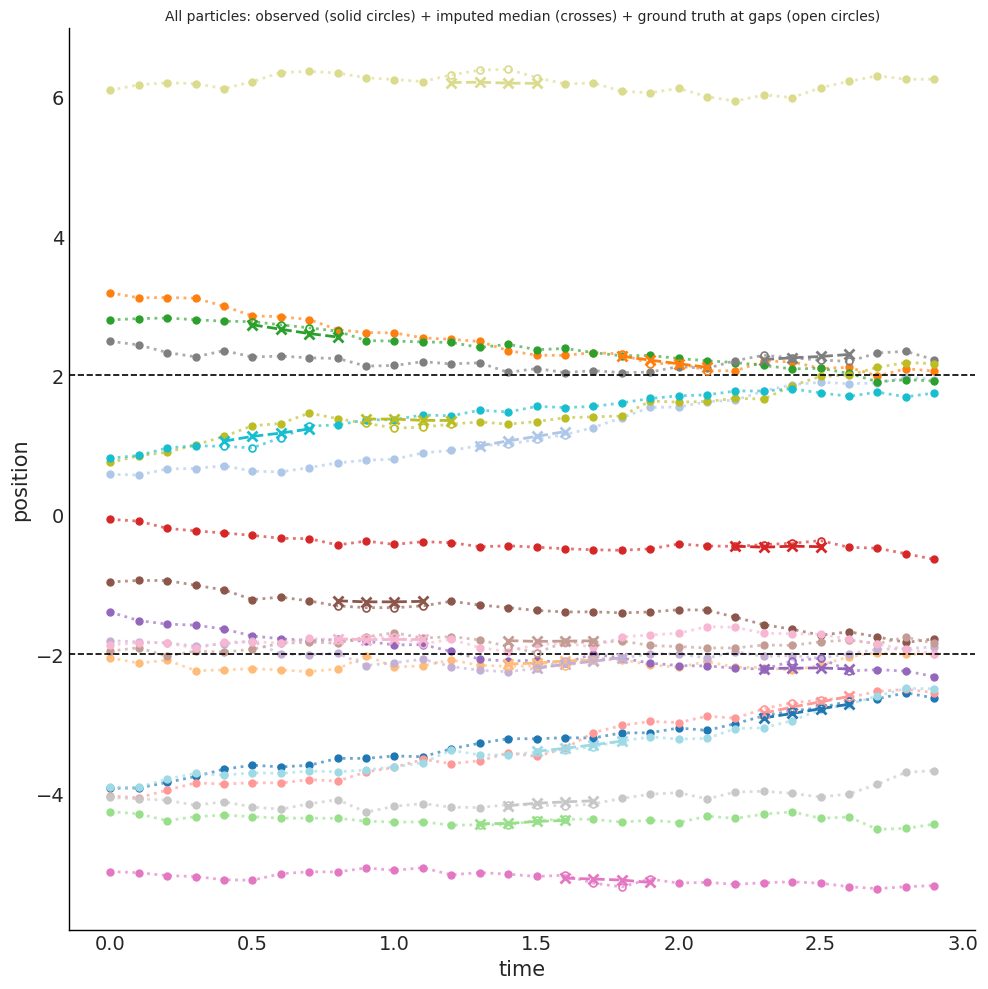

In [51]:
post_svi_p = guide_p.sample_posterior(jr.PRNGKey(10), svi_res_p.params, sample_shape=(200,))
post_coeff_p = np.asarray(post_svi_p["coefficient"])
post_scale_p = np.asarray(post_svi_p["scale"])
print(f"coefficient:  true {true_coeff:+.1f}  |  SVI mean {post_coeff_p.mean():+.3f} ± {post_coeff_p.std():.3f}")
print(f"scale:        true {true_scale:.1f}   |  SVI mean {post_scale_p.mean():.3f} ± {post_scale_p.std():.3f}")

with DiscreteTimeSimulator():
    svi_out_p = Predictive(interacting_particles_model, posterior_samples=post_svi_p)(
        pp_key_p, N=N_p, obs_times=obs_times_p, obs_values=obs_block_p
    )
svi_states_p = np.asarray(svi_out_p["states"])   # (200, T, N)

# ---- Parameter posteriors ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
az.plot_posterior(post_coeff_p, hdi_prob=0.95, ref_val=true_coeff, ax=axes[0])
axes[0].set_title("coefficient  (true = −1)", fontsize=10)
az.plot_posterior(post_scale_p, hdi_prob=0.95, ref_val=true_scale, ax=axes[1])
axes[1].set_title("scale  (true = 1)", fontsize=10)
fig.suptitle("SVI parameter posteriors", fontsize=11)
plt.tight_layout()
plt.show()

# ---- Gap imputation: 4 spotlight particles ----------------------------------
spotlight = [0, 5, 10, 15]
n_draws = 30

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for idx, (ax, i) in enumerate(zip(axes.flat, spotlight)):
    gap_s = gap_starts_p[i]
    gap_e = gap_s + gap_len_p
    obs_i = obs_np_p[:, i]
    observed = ~np.isnan(obs_i)

    ax.plot(t_p[observed], obs_i[observed], ".", ms=4, color="C1", alpha=0.7, zorder=4,
            label="observed")
    ax.plot(t_p, obs_clean_p[:, i], color="black", lw=0.7, ls="--", alpha=0.3, label="true")
    ax.axvspan(t_p[gap_s], t_p[gap_e - 1], color="orange", alpha=0.12)

    lo = max(gap_s - 1, 0)
    hi = min(gap_e + 1, len(t_p))
    for s in range(n_draws):
        ax.plot(t_p[lo:hi], svi_states_p[s, lo:hi, i], color="C0", lw=0.8, alpha=0.3)
    ax.set_title(f"Particle {i}", fontsize=9)
    ax.set_xlabel("time")
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle("SVI gap imputation — posterior sample paths through the gap", fontsize=10)
plt.tight_layout()
plt.show()

# ---- All-particle overview --------------------------------------------------
svi_median_p = np.median(svi_states_p, axis=0)

fig, ax = plt.subplots(figsize=(10, 10))
for i in range(N_p):
    obs_i = obs_np_p[:, i]
    observed = ~np.isnan(obs_i)
    gap_idx = np.where(~observed)[0]

    # Plot observed points (solid circles, solid line)
    ax.plot(t_p[observed], obs_i[observed], marker="o", linestyle="none", color=colors_p[i], ms=5, lw=0.8, label=None)

    # Plot imputed median points at gaps (now as "x" crosses)
    if len(gap_idx):
        ax.plot(t_p[gap_idx], svi_median_p[gap_idx, i], marker="x", ms=7,
                color=colors_p[i], linestyle="--", lw=2.0, mew=2, zorder=5)

    # Plot the clean trajectory (ground truth)
    # For observed segments (where obs is not nan): clean trajectory gets a faint dashed line overlay
    ax.plot(t_p, obs_clean_p[:, i], color=colors_p[i], lw=2.0, ls="dotted", alpha=0.65, zorder=0)
    # Plot the ground truth for the unobserved segments (only at missing points) as open circles
    if len(gap_idx):
        ax.plot(t_p[gap_idx], obs_clean_p[gap_idx, i], marker="o", ms=5, color=colors_p[i], mfc="none", mew=1.2, linestyle="none", zorder=6)

for k in range(bg_centers_p.shape[0]):
    ax.axhline(bg_centers_p[k, 0].item(), color="black", ls="--", lw=1.2)
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title("All particles: observed (solid circles) + imputed median (crosses) + ground truth at gaps (open circles)", fontsize=10)
plt.tight_layout()
plt.show()

## Summary

| Section | Missingness pattern | Key mechanism |
|---|---|---|
| 3.1 | Whole-row, full-length + imputation | `unroll_missing=True` (default) — missing rows sampled from transition |
| 3.2 | Whole-row, shorter output | `unroll_missing=False` — rows filtered before simulation |
| 4 | Per-dimension partial | Per-step scan using `masked_log_prob` (diagonal obs model required) |
| 5 | Per-particle contiguous gaps | Per-step scan; gap states are latent variables; SVI with `AutoNormal` |

**Key takeaways:**

- Pass `NaN` directly in `obs_values` — no preprocessing required.
- Per-dimension partial missingness requires a **diagonal** observation model;
  correlated models (`LinearGaussianObservation`) raise `NotImplementedError`.
- With gap states as latent variables, SVI recovers both model parameters and
  gap trajectories jointly.